In [1]:
import os
os.chdir('../..')
print(os.getcwd())

/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency


In [2]:
import pandas as pd

# Read the file, skipping the first two lines that start with #
df = pd.read_csv('output/mast_out/mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python')
df.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']

# Count unique RBPs in alt_id column
unique_rbps = df['alt_id'].nunique()
print(f"Number of unique RBPs: {unique_rbps}")

# Create new column 'trID' by splitting sequence_name on '_' and taking index 0
df['trID'] = df['sequence_name'].str.split('_').str[0]
df

Number of unique RBPs: 30


,sequence_name,strand,id,alt_id,hit_start,hit_end,score,p_value,trID
0,FBtr0081843_5utr,12,RNCMPT00009,CG33714,12,18,365.21,0.009770,FBtr0081843
1,FBtr0081843_5utr,29,RNCMPT00035,LARK,26,32,-80.54,0.028300,FBtr0081843
2,FBtr0081843_5utr,21,RNCMPT00120,FNE,33,39,392.49,0.005430,FBtr0081843
3,FBtr0081843_5utr,2,RNCMPT00270,ARET,44,50,890.19,0.000366,FBtr0081843
4,FBtr0081843_5utr,5,RNCMPT00134,B52,56,62,457.93,0.003480,FBtr0081843
...,...,...,...,...,...,...,...,...,...
278960,FBtr0089106_3utr,16,RNCMPT00008,CNOT4,349,355,819.90,0.000854,FBtr0089106
278961,FBtr0089106_3utr,9,RNCMPT00131,CG17838,360,366,459.44,0.001950,FBtr0089106
278962,FBtr0089106_3utr,7,RNCMPT00129,CG11360,370,377,622.26,0.002230,FBtr0089106
278963,FBtr0089106_3utr,9,RNCMPT00131,CG17838,379,385,339.38,0.004030,FBtr0089106


In [3]:
# Count alt_ids for each unique trID value
alt_id_counts_per_trID = df.groupby(['trID','alt_id']).count().reset_index().iloc[:,:3]
alt_id_counts_per_trID.columns = ['trID', 'alt_id_count', 'counts']

print("\nAlt_id counts per trID:")
print(alt_id_counts_per_trID)


Alt_id counts per trID:
              trID alt_id_count  counts
0      FBtr0070008        A2BP1       1
1      FBtr0070008         ARET       2
2      FBtr0070008      CG14718       3
3      FBtr0070008      CG17838       3
4      FBtr0070008       CG2931       1
...            ...          ...     ...
88993  FBtr0481736         REF2       4
88994  FBtr0481736        RNP4F       1
88995  FBtr0481736         ROX8       1
88996  FBtr0481736     SNRNP70K       3
88997  FBtr0481736       U2AF50       1

[88998 rows x 3 columns]


In [4]:
# Pivot the dataframe to have trID as rows and alt_id_count as columns with counts as values
alt_id_counts_per_trID_pivoted = alt_id_counts_per_trID.pivot(index='trID', columns='alt_id_count', values='counts').fillna(0).astype(int)
alt_id_counts_per_trID_pivoted.columns = alt_id_counts_per_trID_pivoted.columns+'_rbp'

print("Pivoted dataframe:")
print(alt_id_counts_per_trID_pivoted)

Pivoted dataframe:
alt_id_count  A2BP1_rbp  ARET_rbp  B52_rbp  CG11360_rbp  CG14718_rbp  \
trID                                                                   
FBtr0070008           1         2        0            0            3   
FBtr0070025           2         2        0            1            2   
FBtr0070026           1         3        0            1            2   
FBtr0070038           0         1        1            0            0   
FBtr0070045           0         1        0            0            0   
...                 ...       ...      ...          ...          ...   
FBtr0481650           3         2        1            3            1   
FBtr0481651           3         3        2            1            0   
FBtr0481697           4         2        1            3            5   
FBtr0481735           1         1        3            1            0   
FBtr0481736           2         2        1            2            0   

alt_id_count  CG17838_rbp  CG2931_rbp  CG295

In [5]:
from Bio import SeqIO

# Create dictionary to map trID to TE_value
te_dict = {}

# Read the fasta file and extract trID and TE_value from description
with open('output/data/decay/train.fasta', 'r') as fasta_file:
    for seq_record in SeqIO.parse(fasta_file, 'fasta'):
        description_parts = seq_record.description.split()
        te_value = description_parts[0]
        tr_id = description_parts[1]
        te_dict[tr_id] = te_value

print(f"Created dictionary with {len(te_dict)} entries")
print("First few entries:")
for i, (key, value) in enumerate(te_dict.items()):
    if i < 5:
        print(f"{key}: {value}")
    else:
        break

Created dictionary with 4243 entries
First few entries:
FBtr0081843: 0.34404852416958664
FBtr0084166: 0.7308060935938796
FBtr0100446: 0.7849753945728306
FBtr0078857: 0.610145827906886
FBtr0083574: 0.9239241641828473


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from scipy import stats

# Create a dataframe with TE values for the trIDs in the pivoted dataframe
te_df = pd.DataFrame.from_dict(te_dict, orient='index', columns=['TE_value'])
te_df.index.name = 'trID'

# Convert TE_value to numeric
te_df['TE_value'] = pd.to_numeric(te_df['TE_value'])

# Merge the pivoted dataframe with TE values
merged_df = alt_id_counts_per_trID_pivoted.merge(te_df, left_index=True, right_index=True, how='inner')

In [7]:
te_df

,TE_value
trID,
FBtr0081843,0.344049
FBtr0084166,0.730806
FBtr0100446,0.784975
FBtr0078857,0.610146
FBtr0083574,0.923924
...,...
FBtr0080331,0.670460
FBtr0310541,0.183988
FBtr0089223,0.351764


In [8]:
merged_df

,A2BP1_rbp,ARET_rbp,B52_rbp,CG11360_rbp,CG14718_rbp,CG17838_rbp,CG2931_rbp,CG2950_rbp,CG33714_rbp,CG5213_rbp,...,PUF68_rbp,PUM_rbp,QKR58E-1_rbp,RBP1-LIKE_rbp,REF2_rbp,RNP4F_rbp,ROX8_rbp,SNRNP70K_rbp,U2AF50_rbp,TE_value
trID,,,,,,,,,,,,,,,,,,,,,
FBtr0070008,1,2,0,0,3,3,1,0,0,0,...,2,0,1,2,1,0,3,3,0,0.516353
FBtr0070025,2,2,0,1,2,0,1,0,1,2,...,0,0,2,1,3,1,1,0,1,0.296960
FBtr0070026,1,3,0,1,2,1,0,2,0,2,...,0,1,0,2,0,0,0,0,1,0.321393
FBtr0070038,0,1,1,0,0,2,2,0,0,1,...,0,0,4,0,0,0,2,2,1,0.765322
FBtr0070045,0,1,0,0,0,0,2,0,0,1,...,1,0,0,1,0,1,0,0,0,0.223559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBtr0481650,3,2,1,3,1,3,3,3,2,3,...,2,4,3,3,0,2,4,3,1,0.326041
FBtr0481651,3,3,2,1,0,4,6,4,5,3,...,4,2,9,2,2,3,3,0,4,0.376104
FBtr0481697,4,2,1,3,5,8,6,3,1,3,...,1,7,7,10,8,3,4,1,1,0.509196


In [9]:
# Read the additional feature files
extra_features = pd.read_csv('output/data/codons/extraFeatures.csv',index_col=0).drop(['Residuals','Decay Rate'], axis=1)
vienna_features = pd.read_csv('output/data/codons/vienna_features.csv',index_col=0)[['mfe']]
extra_features

,5' UTR Length,CDS Length,3' UTR Length,5' UTR GC Content,CDS GC Content,3' UTR GC Content,TTT,TTC,TTA,TTG,...,CGT,CGC,CGA,CGG,AGA,AGG,GGT,GGC,GGA,GGG
FBtr0085326,117,3666,317,0.358974,0.487725,0.324921,0.009820,0.005728,0.007365,0.014730,...,0.008183,0.010638,0.005728,0.009002,0.008183,0.005728,0.008183,0.009002,0.013912,0.003273
FBtr0085482,240,1017,667,0.425000,0.587021,0.361319,0.005900,0.032448,0.000000,0.014749,...,0.008850,0.023599,0.000000,0.011799,0.002950,0.005900,0.002950,0.038348,0.032448,0.005900
FBtr0085360,107,918,75,0.355140,0.525054,0.240000,0.013072,0.042484,0.000000,0.026144,...,0.016340,0.013072,0.009804,0.016340,0.006536,0.006536,0.009804,0.006536,0.013072,0.003268
FBtr0113386,233,3192,761,0.424893,0.536654,0.363995,0.003759,0.017857,0.002820,0.009398,...,0.005639,0.012218,0.017857,0.014098,0.011278,0.007519,0.007519,0.024436,0.015038,0.006579
FBtr0084017,169,1014,326,0.491124,0.561144,0.368098,0.023669,0.035503,0.002959,0.020710,...,0.002959,0.023669,0.008876,0.002959,0.000000,0.005917,0.017751,0.026627,0.029586,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBtr0089245,590,8613,563,0.325424,0.414374,0.268206,0.022989,0.011494,0.022640,0.012887,...,0.008708,0.004180,0.009056,0.003483,0.014281,0.007315,0.012539,0.007315,0.020202,0.006966
FBtr0333699,98,540,77,0.285714,0.424074,0.259740,0.027778,0.011111,0.011111,0.038889,...,0.016667,0.022222,0.005556,0.000000,0.005556,0.011111,0.022222,0.016667,0.022222,0.005556
FBtr0089094,869,1794,390,0.309551,0.376812,0.246154,0.016722,0.035117,0.023411,0.025084,...,0.001672,0.005017,0.008361,0.010033,0.010033,0.010033,0.008361,0.003344,0.010033,0.006689
FBtr0089085,331,3240,117,0.317221,0.393827,0.384615,0.036111,0.011111,0.022222,0.017593,...,0.010185,0.006481,0.007407,0.003704,0.010185,0.005556,0.012037,0.009259,0.019444,0.007407


In [10]:
vienna_features

,mfe
id,
FBtr0078486,232.11
FBtr0078892,91.79
FBtr0071350,172.98
FBtr0301734,26.22
FBtr0344326,472.15
...,...
FBtr0085776,67.21
FBtr0083255,118.68
FBtr0073806,77.68


In [11]:
# Merge the additional features with the existing merged_df
merged_df = merged_df.merge(extra_features, left_index=True, right_index=True, how='left')
merged_df = merged_df.merge(vienna_features, left_index=True, right_index=True, how='left')
merged_df.dropna(inplace=True)

print(f"Updated merged_df shape: {merged_df.shape}")
print(f"New columns added: {merged_df.columns.tolist()}")

Updated merged_df shape: (4240, 99)
New columns added: ['A2BP1_rbp', 'ARET_rbp', 'B52_rbp', 'CG11360_rbp', 'CG14718_rbp', 'CG17838_rbp', 'CG2931_rbp', 'CG2950_rbp', 'CG33714_rbp', 'CG5213_rbp', 'CG7804_rbp', 'CG7903_rbp', 'CNOT4_rbp', 'CPO_rbp', 'FNE_rbp', 'HRB27C_rbp', 'HRB87F_rbp', 'LARK_rbp', 'MOD_rbp', 'MUB_rbp', 'PABP_rbp', 'PUF68_rbp', 'PUM_rbp', 'QKR58E-1_rbp', 'RBP1-LIKE_rbp', 'REF2_rbp', 'RNP4F_rbp', 'ROX8_rbp', 'SNRNP70K_rbp', 'U2AF50_rbp', 'TE_value', "5' UTR Length", 'CDS Length', "3' UTR Length", "5' UTR GC Content", 'CDS GC Content', "3' UTR GC Content", 'TTT', 'TTC', 'TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG', 'ATT', 'ATC', 'ATA', 'ATG', 'GTT', 'GTC', 'GTA', 'GTG', 'TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC', 'CCT', 'CCC', 'CCA', 'CCG', 'ACT', 'ACC', 'ACA', 'ACG', 'GCT', 'GCC', 'GCA', 'GCG', 'TAT', 'TAC', 'CAT', 'CAC', 'CAA', 'CAG', 'AAT', 'AAC', 'AAA', 'AAG', 'GAT', 'GAC', 'GAA', 'GAG', 'TGT', 'TGC', 'TGG', 'CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GGT', 'GGC', 'GGA', 'GGG'

In [12]:
merged_df

,A2BP1_rbp,ARET_rbp,B52_rbp,CG11360_rbp,CG14718_rbp,CG17838_rbp,CG2931_rbp,CG2950_rbp,CG33714_rbp,CG5213_rbp,...,CGC,CGA,CGG,AGA,AGG,GGT,GGC,GGA,GGG,mfe
trID,,,,,,,,,,,,,,,,,,,,,
FBtr0070008,1,2,0,0,3,3,1,0,0,0,...,0.022059,0.007353,0.018382,0.000000,0.000000,0.000000,0.014706,0.003676,0.003676,73.94
FBtr0070025,2,2,0,1,2,0,1,0,1,2,...,0.025000,0.006250,0.034375,0.037500,0.075000,0.003125,0.006250,0.012500,0.003125,145.67
FBtr0070026,1,3,0,1,2,1,0,2,0,2,...,0.045872,0.001835,0.005505,0.000000,0.001835,0.009174,0.045872,0.007339,0.009174,194.51
FBtr0070038,0,1,1,0,0,2,2,0,0,1,...,0.005453,0.008724,0.006543,0.017448,0.011996,0.000000,0.002181,0.023991,0.005453,73.55
FBtr0070045,0,1,0,0,0,0,2,0,0,1,...,0.004292,0.010014,0.002861,0.007153,0.001431,0.007153,0.005722,0.011445,0.001431,21.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBtr0481650,3,2,1,3,1,3,3,3,2,3,...,0.015845,0.010563,0.004401,0.007042,0.000880,0.013204,0.031690,0.027289,0.002641,269.47
FBtr0481651,3,3,2,1,0,4,6,4,5,3,...,0.026804,0.004124,0.008247,0.004124,0.006186,0.010309,0.016495,0.004124,0.000000,107.68
FBtr0481697,4,2,1,3,5,8,6,3,1,3,...,0.018277,0.005222,0.003916,0.003916,0.005222,0.028721,0.057441,0.023499,0.002611,250.48


In [13]:


# Prepare features (X) and target (y)
X = merged_df.drop('TE_value', axis=1)
y = merged_df['TE_value']


In [14]:
y

trID
FBtr0070008    0.516353
FBtr0070025    0.296960
FBtr0070026    0.321393
FBtr0070038    0.765322
FBtr0070045    0.223559
                 ...   
FBtr0481650    0.326041
FBtr0481651    0.376104
FBtr0481697    0.509196
FBtr0481735    0.538157
FBtr0481736    0.440590
Name: TE_value, Length: 4240, dtype: float64

In [15]:
X

,A2BP1_rbp,ARET_rbp,B52_rbp,CG11360_rbp,CG14718_rbp,CG17838_rbp,CG2931_rbp,CG2950_rbp,CG33714_rbp,CG5213_rbp,...,CGC,CGA,CGG,AGA,AGG,GGT,GGC,GGA,GGG,mfe
trID,,,,,,,,,,,,,,,,,,,,,
FBtr0070008,1,2,0,0,3,3,1,0,0,0,...,0.022059,0.007353,0.018382,0.000000,0.000000,0.000000,0.014706,0.003676,0.003676,73.94
FBtr0070025,2,2,0,1,2,0,1,0,1,2,...,0.025000,0.006250,0.034375,0.037500,0.075000,0.003125,0.006250,0.012500,0.003125,145.67
FBtr0070026,1,3,0,1,2,1,0,2,0,2,...,0.045872,0.001835,0.005505,0.000000,0.001835,0.009174,0.045872,0.007339,0.009174,194.51
FBtr0070038,0,1,1,0,0,2,2,0,0,1,...,0.005453,0.008724,0.006543,0.017448,0.011996,0.000000,0.002181,0.023991,0.005453,73.55
FBtr0070045,0,1,0,0,0,0,2,0,0,1,...,0.004292,0.010014,0.002861,0.007153,0.001431,0.007153,0.005722,0.011445,0.001431,21.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBtr0481650,3,2,1,3,1,3,3,3,2,3,...,0.015845,0.010563,0.004401,0.007042,0.000880,0.013204,0.031690,0.027289,0.002641,269.47
FBtr0481651,3,3,2,1,0,4,6,4,5,3,...,0.026804,0.004124,0.008247,0.004124,0.006186,0.010309,0.016495,0.004124,0.000000,107.68
FBtr0481697,4,2,1,3,5,8,6,3,1,3,...,0.018277,0.005222,0.003916,0.003916,0.005222,0.028721,0.057441,0.023499,0.002611,250.48


In [16]:
# Check for NaN values in X
print("NaN values in X:")
print(X.isnull().sum())
print(f"\nTotal NaN values: {X.isnull().sum().sum()}")

# Show which rows have NaN values
rows_with_nan = X.isnull().any(axis=1)
print(f"\nNumber of rows with NaN values: {rows_with_nan.sum()}")

if rows_with_nan.sum() > 0:
    print("\nRows with NaN values:")
    print(X[rows_with_nan].index.tolist())
    
    # Show which columns have NaN for these rows
    print("\nColumns with NaN values for affected rows:")
    for col in X.columns:
        if X[col].isnull().any():
            print(f"{col}: {X[col].isnull().sum()} NaN values")

NaN values in X:
A2BP1_rbp      0
ARET_rbp       0
B52_rbp        0
CG11360_rbp    0
CG14718_rbp    0
              ..
GGT            0
GGC            0
GGA            0
GGG            0
mfe            0
Length: 98, dtype: int64

Total NaN values: 0

Number of rows with NaN values: 0


In [17]:
# Create and fit the linear regression model using all data
model = LinearRegression()
model.fit(X, y)

# Make predictions on the same data
y_pred = model.predict(X)

# Calculate p-values for coefficients
n = X.shape[0]  # number of observations
p = X.shape[1]  # number of features
dof = n - p - 1  # degrees of freedom

# Calculate residuals and mean squared error
residuals = y - y_pred
mse = np.sum(residuals**2) / dof

# Calculate standard errors
X_with_intercept = np.column_stack([np.ones(n), X])
try:
    cov_matrix = mse * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
    std_errors = np.sqrt(np.diag(cov_matrix)[1:])  # exclude intercept
    
    # Calculate t-statistics and p-values
    t_stats = model.coef_ / std_errors
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'RBP': X.columns,
        'Coefficient': model.coef_,
        'Std_Error': std_errors,
        'T_Statistic': t_stats,
        'P_Value': p_values
    }).sort_values('P_Value')
    
    print("Coefficients with p-values:")
    print(results_df)
    
except np.linalg.LinAlgError:
    print("Could not calculate p-values due to singular matrix")
    # Fallback to original results
    feature_importance = pd.DataFrame({
        'RBP': X.columns,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print("\nTop 10 most important features:")
    print(feature_importance.head(10))

# Print model performance
print(f"\nR² Score: {r2_score(y, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred):.4f}")
print(f"Root Mean Squared Error: {mean_squared_error(y, y_pred)**0.5:.4f}")


Coefficients with p-values:
                  RBP  Coefficient  Std_Error  T_Statistic   P_Value
35  3' UTR GC Content    -0.253995   0.061923    -4.101774  0.000042
72                CAT    -2.902339   0.773923    -3.750162  0.000179
33  5' UTR GC Content    -0.200984   0.054762    -3.670145  0.000245
37                TTC    -2.522246   0.698696    -3.609933  0.000310
54                TCA    -2.616727   0.886612    -2.951377  0.003181
..                ...          ...        ...          ...       ...
92                AGG    -0.208846   1.926984    -0.108380  0.913700
25           REF2_rbp    -0.000199   0.003020    -0.065955  0.947417
79                AAG    -0.034082   0.628611    -0.054217  0.956765
44                ATT     0.037231   1.063910     0.034995  0.972086
20           PABP_rbp    -0.000055   0.002210    -0.025109  0.979969

[98 rows x 5 columns]

R² Score: 0.2692
Mean Squared Error: 0.0442
Root Mean Squared Error: 0.2103


In [18]:
RBPrank = []
# Sort results_df by T_Statistic from high to low
results_df_sorted = results_df.sort_values('T_Statistic', ascending=False)

for index, row in results_df_sorted.iterrows():
    if '_rbp' in row['RBP']:
        RBPrank.append(row['RBP'].split('_')[0])
        print(index, [round(val, 2) if isinstance(val, float) else val for val in row.values])
    #print(f"Index: {index}, RBP: {row['RBP']}, Coefficient: {row['Coefficient']:.6f}, Std_Error: {row['Std_Error']:.6f}, T_Statistic: {row['T_Statistic']:.6f}, P_Value: {row['P_Value']:.6f}")


26 ['RNP4F_rbp', 0.0, 0.0, 1.25, 0.21]
2 ['B52_rbp', 0.0, 0.0, 0.99, 0.32]
7 ['CG2950_rbp', 0.0, 0.0, 0.89, 0.37]
15 ['HRB27C_rbp', 0.0, 0.0, 0.44, 0.66]
16 ['HRB87F_rbp', 0.0, 0.0, 0.32, 0.75]
12 ['CNOT4_rbp', 0.0, 0.0, 0.19, 0.85]
18 ['MOD_rbp', 0.0, 0.0, 0.15, 0.88]
3 ['CG11360_rbp', 0.0, 0.0, 0.12, 0.9]
20 ['PABP_rbp', -0.0, 0.0, -0.03, 0.98]
25 ['REF2_rbp', -0.0, 0.0, -0.07, 0.95]
17 ['LARK_rbp', -0.0, 0.0, -0.18, 0.86]
8 ['CG33714_rbp', -0.0, 0.0, -0.25, 0.8]
10 ['CG7804_rbp', -0.0, 0.0, -0.35, 0.73]
22 ['PUM_rbp', -0.0, 0.0, -0.42, 0.67]
28 ['SNRNP70K_rbp', -0.0, 0.0, -0.46, 0.65]
19 ['MUB_rbp', -0.0, 0.0, -0.54, 0.59]
27 ['ROX8_rbp', -0.0, 0.0, -0.64, 0.53]
4 ['CG14718_rbp', -0.0, 0.0, -0.64, 0.52]
6 ['CG2931_rbp', -0.0, 0.0, -0.71, 0.47]
23 ['QKR58E-1_rbp', -0.0, 0.0, -0.74, 0.46]
13 ['CPO_rbp', -0.0, 0.0, -0.83, 0.41]
24 ['RBP1-LIKE_rbp', -0.0, 0.0, -0.91, 0.36]
21 ['PUF68_rbp', -0.0, 0.0, -0.92, 0.36]
11 ['CG7903_rbp', -0.0, 0.0, -1.17, 0.24]
0 ['A2BP1_rbp', -0.0, 0.0, -1.6,

In [19]:
RBPrank


['RNP4F',
 'B52',
 'CG2950',
 'HRB27C',
 'HRB87F',
 'CNOT4',
 'MOD',
 'CG11360',
 'PABP',
 'REF2',
 'LARK',
 'CG33714',
 'CG7804',
 'PUM',
 'SNRNP70K',
 'MUB',
 'ROX8',
 'CG14718',
 'CG2931',
 'QKR58E-1',
 'CPO',
 'RBP1-LIKE',
 'PUF68',
 'CG7903',
 'A2BP1',
 'CG17838',
 'ARET',
 'CG5213',
 'FNE',
 'U2AF50']

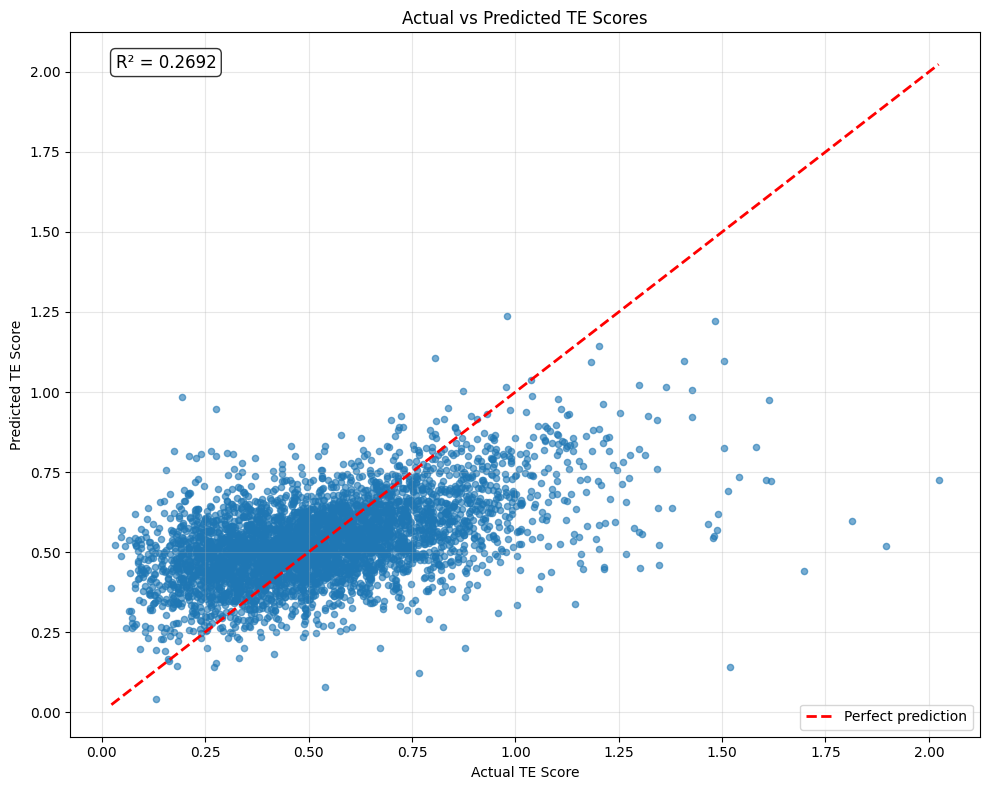

In [20]:
import matplotlib.pyplot as plt

# Create scatter plot of actual vs predicted TE scores
plt.figure(figsize=(10, 8))
plt.scatter(y, y_pred, alpha=0.6, s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual TE Score')
plt.ylabel('Predicted TE Score')
plt.title('Actual vs Predicted TE Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² score to the plot
plt.text(0.05, 0.95, f'R² = {r2_score(y, y_pred):.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

Binary model - Coefficients with p-values:
                  RBP  Coefficient  Std_Error  T_Statistic   P_Value
42                CAT    -2.894796   0.773730    -3.741354  0.000185
7                 TTC    -2.484591   0.699137    -3.553798  0.000384
3   5' UTR GC Content    -0.170450   0.052157    -3.268029  0.001092
5   3' UTR GC Content    -0.173752   0.056819    -3.058016  0.002242
22                TCT    -2.643497   0.901625    -2.931924  0.003387
..                ...          ...        ...          ...       ...
67                mfe    -0.000016   0.000076    -0.206755  0.836211
17                ATG    -0.100260   0.679626    -0.147523  0.882726
14                ATT    -0.090176   1.062728    -0.084853  0.932382
62                AGG    -0.132438   1.924486    -0.068817  0.945139
49                AAG     0.013296   0.628635     0.021151  0.983127

[68 rows x 5 columns]

Binary model - R² Score: 0.2588
Binary model - Mean Squared Error: 0.0448
Binary model - Root Mean Square

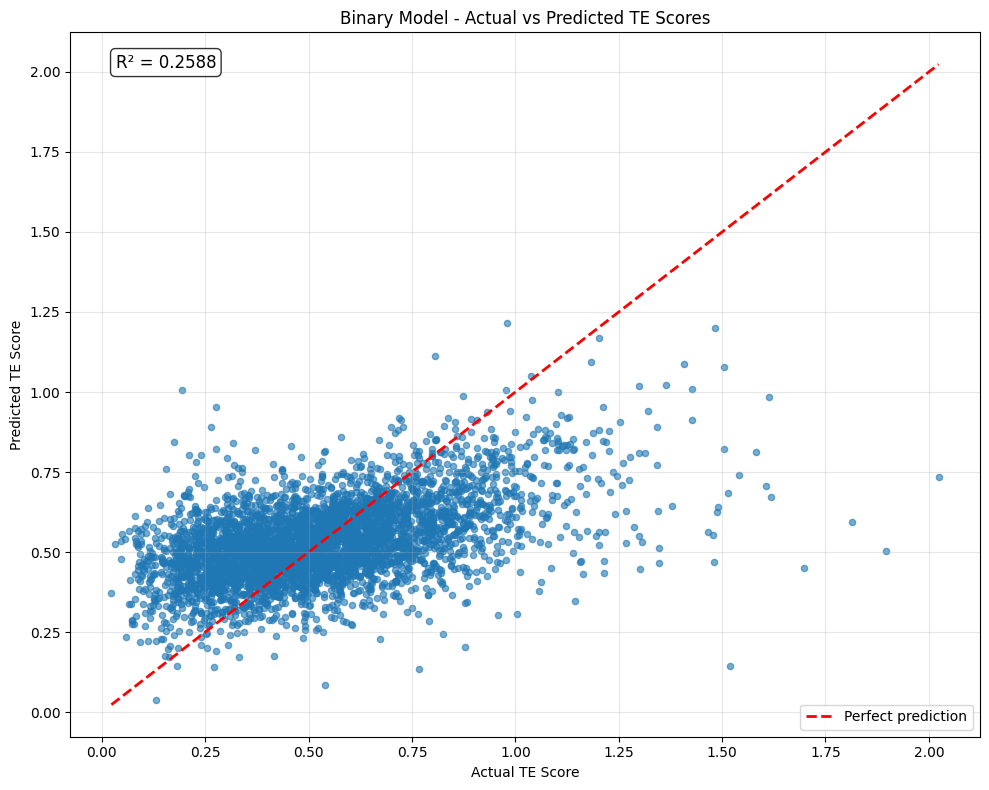

In [23]:
# Create binary version of the count data (1 if count > 0, 0 otherwise)
X_binary = X.drop(columns=X.columns[['_rbp' in c for c in X.columns]])

# Create and fit the linear regression model using binary data
model_binary = LinearRegression()
model_binary.fit(X_binary, y)

# Make predictions on the same data
y_pred_binary = model_binary.predict(X_binary)

# Calculate p-values for coefficients
n = X_binary.shape[0]  # number of observations
p = X_binary.shape[1]  # number of features
dof = n - p - 1  # degrees of freedom

# Calculate residuals and mean squared error
residuals_binary = y - y_pred_binary
mse_binary = np.sum(residuals_binary**2) / dof

# Calculate standard errors
X_binary_with_intercept = np.column_stack([np.ones(n), X_binary])
try:
    cov_matrix_binary = mse_binary * np.linalg.inv(X_binary_with_intercept.T @ X_binary_with_intercept)
    std_errors_binary = np.sqrt(np.diag(cov_matrix_binary)[1:])  # exclude intercept
    
    # Calculate t-statistics and p-values
    t_stats_binary = model_binary.coef_ / std_errors_binary
    p_values_binary = 2 * (1 - stats.t.cdf(np.abs(t_stats_binary), dof))
    
    # Create results dataframe
    results_df_binary = pd.DataFrame({
        'RBP': X_binary.columns,
        'Coefficient': model_binary.coef_,
        'Std_Error': std_errors_binary,
        'T_Statistic': t_stats_binary,
        'P_Value': p_values_binary
    }).sort_values('P_Value')
    
    print("Binary model - Coefficients with p-values:")
    print(results_df_binary)
    
except np.linalg.LinAlgError:
    print("Could not calculate p-values due to singular matrix")
    # Fallback to original results
    feature_importance_binary = pd.DataFrame({
        'RBP': X_binary.columns,
        'Coefficient': model_binary.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print("\nBinary model - Top 10 most important features:")
    print(feature_importance_binary.head(10))

# Print model performance
print(f"\nBinary model - R² Score: {r2_score(y, y_pred_binary):.4f}")
print(f"Binary model - Mean Squared Error: {mean_squared_error(y, y_pred_binary):.4f}")
print(f"Binary model - Root Mean Squared Error: {mean_squared_error(y, y_pred_binary)**0.5:.4f}")

# Create scatter plot of actual vs predicted TE scores for binary model
plt.figure(figsize=(10, 8))
plt.scatter(y, y_pred_binary, alpha=0.6, s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual TE Score')
plt.ylabel('Predicted TE Score')
plt.title('Binary Model - Actual vs Predicted TE Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² score to the plot
plt.text(0.05, 0.95, f'R² = {r2_score(y, y_pred_binary):.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

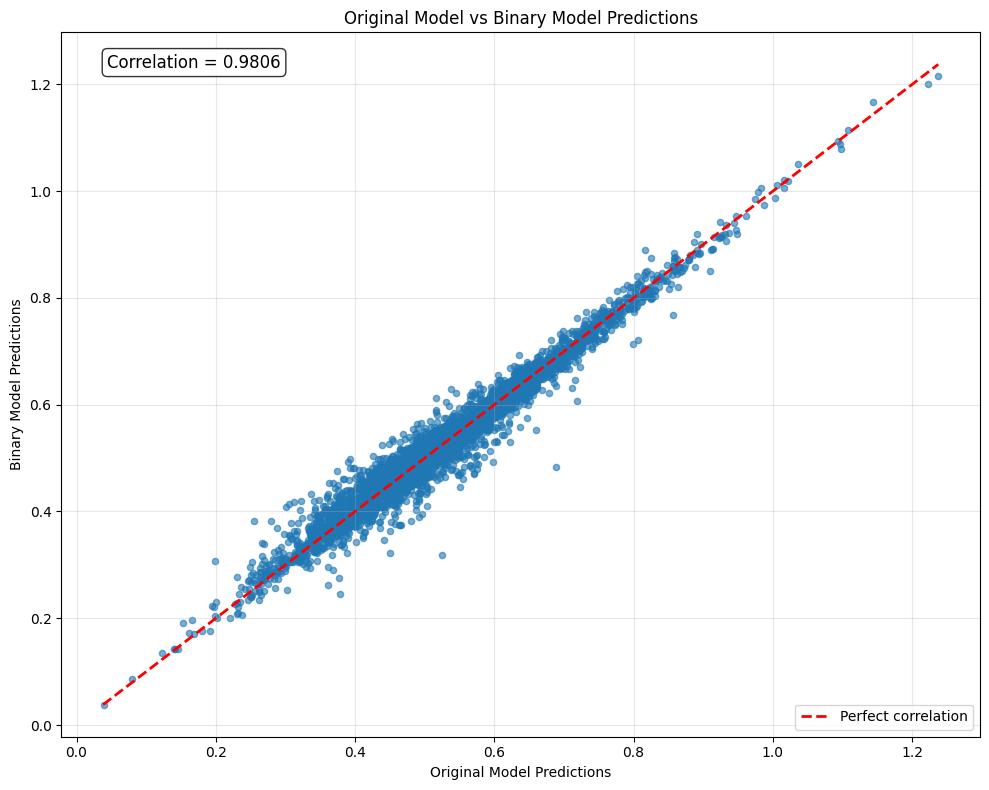

In [24]:
myDiff = y_pred - y_pred_binary

plt.figure(figsize=(10, 8))
plt.scatter(y_pred, y_pred_binary, alpha=0.6, s=20)
plt.plot([min(y_pred.min(), y_pred_binary.min()), max(y_pred.max(), y_pred_binary.max())], 
         [min(y_pred.min(), y_pred_binary.min()), max(y_pred.max(), y_pred_binary.max())], 
         'r--', lw=2, label='Perfect correlation')
plt.xlabel('Original Model Predictions')
plt.ylabel('Binary Model Predictions')
plt.title('Original Model vs Binary Model Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

# Add correlation coefficient to the plot
correlation = np.corrcoef(y_pred, y_pred_binary)[0, 1]
plt.text(0.05, 0.95, f'Correlation = {correlation:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# logistic regression

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# Scale the features before filtering
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Create quintiles based on y values (high to low ranking)
y_quintiles = pd.qcut(y, q=5, labels=['Bottom', 'Low', 'Middle', 'High', 'Top'])

# Create binary target: Top 2 quintiles = 1, Bottom 2 quintiles = 0, Middle quintile removed
y_binary_quintiles = y_quintiles.copy()
y_binary_quintiles = y_binary_quintiles.replace({'Top': 1, 'High': 1, 'Bottom': 0, 'Low': 0})

# Remove middle quintile
mask = y_quintiles != 'Middle'
X_filtered = X_scaled[mask]
y_filtered = y_binary_quintiles[mask]
# Convert to numeric after filtering
y_filtered = pd.to_numeric(y_filtered, errors='coerce').astype(int)

# Create and fit the logistic regression model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_filtered, y_filtered)

# Make predictions
y_pred = model.predict(X_filtered)
y_pred_proba = model.predict_proba(X_filtered)[:, 1]

# Calculate p-values for logistic regression coefficients
n = X_filtered.shape[0]
p = X_filtered.shape[1]

# Calculate standard errors using the inverse of the Hessian matrix
predictions = model.predict_proba(X_filtered)[:, 1]
W = np.diag(predictions * (1 - predictions))
X_design = X_filtered.values
H = X_design.T @ W @ X_design
try:
    inv_H = np.linalg.inv(H)
    std_errors = np.sqrt(np.diag(inv_H))
    
    # Calculate z-statistics and p-values
    z_stats = model.coef_[0] / std_errors
    p_values = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))
    
    # Create results dataframe with p-values
    results_df = pd.DataFrame({
        'Feature': X_filtered.columns,
        'Coefficient': model.coef_[0],
        'Std_Error': std_errors,
        'Z_Statistic': z_stats,
        'P_Value': p_values
    }).sort_values('P_Value')
    
    print("Logistic Regression - Coefficients with p-values:")
    print(results_df)
    
except np.linalg.LinAlgError:
    print("Could not calculate p-values due to singular matrix")
    # Fallback to original results without p-values
    results_df = pd.DataFrame({
        'Feature': X_filtered.columns,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    print("\nLogistic Regression - Top 10 most important features:")
    print(results_df.head(10))

# Calculate performance metrics
accuracy = accuracy_score(y_filtered, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_filtered, y_pred))

# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_filtered, y_pred))


Logistic Regression - Coefficients with p-values:
              Feature  Coefficient  Std_Error  Z_Statistic   P_Value
33  5' UTR GC Content    -0.170968   0.047071    -3.632142  0.000281
35  3' UTR GC Content    -0.155828   0.049202    -3.167106  0.001540
72                CAT    -0.193376   0.088214    -2.192112  0.028371
91                AGA     0.256732   0.117466     2.185578  0.028847
14            FNE_rbp    -0.181491   0.088678    -2.046621  0.040695
..                ...          ...        ...          ...       ...
27           ROX8_rbp    -0.003775   0.097882    -0.038571  0.969233
70                TAT     0.003144   0.091942     0.034198  0.972719
81                GAC    -0.008546   0.293618    -0.029107  0.976779
76                AAT     0.002203   0.126244     0.017448  0.986079
20           PABP_rbp     0.000230   0.114458     0.002005  0.998400

[98 rows x 5 columns]

Accuracy: 0.7096

Classification Report:
              precision    recall  f1-score   support

  

In [41]:
RBPrank_logistic = []
# Sort results_df by T_Statistic from high to low
results_df_sorted = results_df.sort_values('Z_Statistic', ascending=False)

for index, row in results_df_sorted.iterrows():
    if '_rbp' in row['Feature']:
        RBPrank_logistic.append(row['Feature'].split('_')[0])
        print(index, [round(val, 2) if isinstance(val, float) else val for val in row.values])
    #print(f"Index: {index}, RBP: {row['RBP']}, Coefficient: {row['Coefficient']:.6f}, Std_Error: {row['Std_Error']:.6f}, T_Statistic: {row['T_Statistic']:.6f}, P_Value: {row['P_Value']:.6f}")


2 ['B52_rbp', 0.12, 0.08, 1.49, 0.14]
7 ['CG2950_rbp', 0.15, 0.1, 1.48, 0.14]
12 ['CNOT4_rbp', 0.17, 0.13, 1.27, 0.2]
26 ['RNP4F_rbp', 0.1, 0.08, 1.24, 0.22]
18 ['MOD_rbp', 0.09, 0.09, 1.04, 0.3]
15 ['HRB27C_rbp', 0.06, 0.06, 0.92, 0.36]
25 ['REF2_rbp', 0.08, 0.09, 0.89, 0.38]
10 ['CG7804_rbp', 0.06, 0.06, 0.88, 0.38]
3 ['CG11360_rbp', 0.06, 0.08, 0.76, 0.45]
8 ['CG33714_rbp', 0.01, 0.08, 0.17, 0.86]
22 ['PUM_rbp', 0.01, 0.09, 0.13, 0.9]
20 ['PABP_rbp', 0.0, 0.11, 0.0, 1.0]
27 ['ROX8_rbp', -0.0, 0.1, -0.04, 0.97]
28 ['SNRNP70K_rbp', -0.0, 0.08, -0.05, 0.96]
16 ['HRB87F_rbp', -0.0, 0.06, -0.07, 0.94]
17 ['LARK_rbp', -0.01, 0.08, -0.09, 0.93]
4 ['CG14718_rbp', -0.01, 0.1, -0.09, 0.93]
6 ['CG2931_rbp', -0.01, 0.1, -0.11, 0.91]
19 ['MUB_rbp', -0.03, 0.09, -0.32, 0.75]
24 ['RBP1-LIKE_rbp', -0.06, 0.11, -0.57, 0.57]
21 ['PUF68_rbp', -0.04, 0.06, -0.66, 0.51]
13 ['CPO_rbp', -0.06, 0.09, -0.71, 0.48]
11 ['CG7903_rbp', -0.06, 0.08, -0.75, 0.45]
23 ['QKR58E-1_rbp', -0.09, 0.11, -0.82, 0.41]
0 ['

In [45]:
for i in range(len(RBPrank_logistic)):
    print(f'{RBPrank_logistic[i]}\t\t{RBPrank[i]}')

B52		RNP4F
CG2950		B52
CNOT4		CG2950
RNP4F		HRB27C
MOD		HRB87F
HRB27C		CNOT4
REF2		MOD
CG7804		CG11360
CG11360		PABP
CG33714		REF2
PUM		LARK
PABP		CG33714
ROX8		CG7804
SNRNP70K		PUM
HRB87F		SNRNP70K
LARK		MUB
CG14718		ROX8
CG2931		CG14718
MUB		CG2931
RBP1-LIKE		QKR58E-1
PUF68		CPO
CPO		RBP1-LIKE
CG7903		PUF68
QKR58E-1		CG7903
A2BP1		A2BP1
CG17838		CG17838
CG5213		ARET
U2AF50		CG5213
ARET		FNE
FNE		U2AF50


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.stats as stats

# Scale the features before filtering
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Create quintiles based on y values (high to low ranking)
y_quintiles = pd.qcut(y, q=5, labels=['Bottom', 'Low', 'Middle', 'High', 'Top'])

# Create binary target: Top 2 quintiles = 1, Bottom 2 quintiles = 0, Middle quintile removed
y_binary_quintiles = y_quintiles.copy()
y_binary_quintiles = y_binary_quintiles.replace({'Top': 1, 'High': 1, 'Bottom': 0, 'Low': 0})

# Remove middle quintile
mask = y_quintiles != 'Middle'
X_filtered = X_scaled[mask]
X_filtered = X_filtered.drop(columns=X_filtered.columns[['_rbp' not in c for c in X_filtered.columns]])
y_filtered = y_binary_quintiles[mask]
# Convert to numeric after filtering
y_filtered = pd.to_numeric(y_filtered, errors='coerce').astype(int)

# Create and fit the logistic regression model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_filtered, y_filtered)

# Make predictions
y_pred = model.predict(X_filtered)
y_pred_proba = model.predict_proba(X_filtered)[:, 1]

# Calculate p-values for logistic regression coefficients
n = X_filtered.shape[0]
p = X_filtered.shape[1]

# Calculate standard errors using the inverse of the Hessian matrix
predictions = model.predict_proba(X_filtered)[:, 1]
W = np.diag(predictions * (1 - predictions))
X_design = X_filtered.values
H = X_design.T @ W @ X_design
try:
    inv_H = np.linalg.inv(H)
    std_errors = np.sqrt(np.diag(inv_H))
    
    # Calculate z-statistics and p-values
    z_stats = model.coef_[0] / std_errors
    p_values = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))
    
    # Create results dataframe with p-values
    results_df = pd.DataFrame({
        'Feature': X_filtered.columns,
        'Coefficient': model.coef_[0],
        'Std_Error': std_errors,
        'Z_Statistic': z_stats,
        'P_Value': p_values
    }).sort_values('P_Value')
    
    print("Logistic Regression - Coefficients with p-values:")
    print(results_df)
    
except np.linalg.LinAlgError:
    print("Could not calculate p-values due to singular matrix")
    # Fallback to original results without p-values
    results_df = pd.DataFrame({
        'Feature': X_filtered.columns,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    print("\nLogistic Regression - Top 10 most important features:")
    print(results_df.head(10))

# Calculate performance metrics
accuracy = accuracy_score(y_filtered, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_filtered, y_pred))

# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_filtered, y_pred))


Logistic Regression - Coefficients with p-values:
          Feature  Coefficient  Std_Error  Z_Statistic   P_Value
14        FNE_rbp    -0.154931   0.057190    -2.709062  0.006747
1        ARET_rbp    -0.162323   0.060492    -2.683382  0.007288
12      CNOT4_rbp     0.160387   0.076470     2.097403  0.035958
0       A2BP1_rbp    -0.111632   0.060123    -1.856726  0.063350
13        CPO_rbp    -0.111547   0.062913    -1.773022  0.076225
11     CG7903_rbp    -0.093055   0.056854    -1.636745  0.101684
15     HRB27C_rbp     0.071151   0.048760     1.459218  0.144505
28   SNRNP70K_rbp     0.070430   0.054669     1.288295  0.197643
26      RNP4F_rbp     0.076127   0.059414     1.281299  0.200089
19        MUB_rbp    -0.075767   0.060342    -1.255624  0.209252
29     U2AF50_rbp    -0.067394   0.054715    -1.231716  0.218055
7      CG2950_rbp     0.083539   0.069001     1.210686  0.226016
8     CG33714_rbp    -0.064990   0.056292    -1.154521  0.248287
21      PUF68_rbp    -0.054041   0.04976

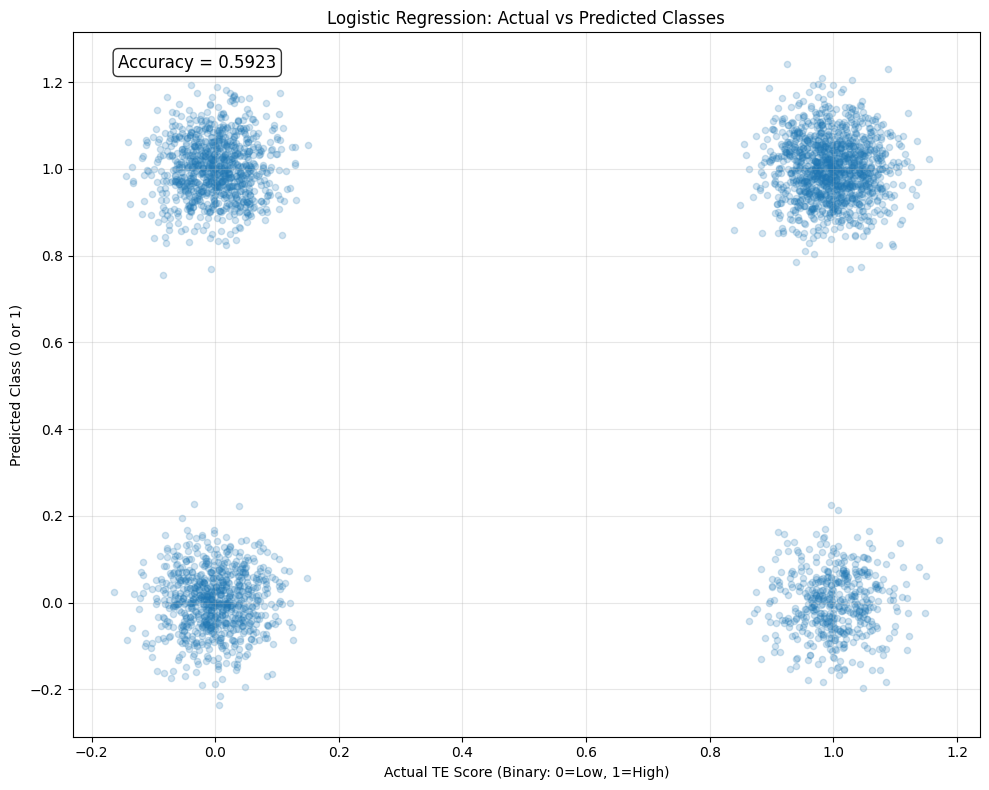

In [55]:
plt.figure(figsize=(10, 8))
# Add jitter to y_filtered for better visualization
jitter_strength = 0.05
y_jittered = y_filtered + np.random.normal(0, jitter_strength, len(y_filtered))
y_pred = y_pred + np.random.normal(0, jitter_strength, len(y_filtered))
plt.scatter(y_jittered, y_pred, alpha=0.2, s=20)
plt.xlabel('Actual TE Score (Binary: 0=Low, 1=High)')
plt.ylabel('Predicted Class (0 or 1)')
plt.title('Logistic Regression: Actual vs Predicted Classes')
plt.grid(True, alpha=0.3)

# Add accuracy to the plot
plt.text(0.05, 0.95, f'Accuracy = {accuracy:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [49]:
RBPrank_logistic = []
# Sort results_df by T_Statistic from high to low
results_df_sorted = results_df.sort_values('Z_Statistic', ascending=False)

for index, row in results_df_sorted.iterrows():
    if '_rbp' in row['Feature']:
        RBPrank_logistic.append(row['Feature'].split('_')[0])
        print(index, [round(val, 2) if isinstance(val, float) else val for val in row.values])
    #print(f"Index: {index}, RBP: {row['RBP']}, Coefficient: {row['Coefficient']:.6f}, Std_Error: {row['Std_Error']:.6f}, T_Statistic: {row['T_Statistic']:.6f}, P_Value: {row['P_Value']:.6f}")


12 ['CNOT4_rbp', 0.16, 0.08, 2.1, 0.04]
15 ['HRB27C_rbp', 0.07, 0.05, 1.46, 0.14]
28 ['SNRNP70K_rbp', 0.07, 0.05, 1.29, 0.2]
26 ['RNP4F_rbp', 0.08, 0.06, 1.28, 0.2]
7 ['CG2950_rbp', 0.08, 0.07, 1.21, 0.23]
25 ['REF2_rbp', 0.07, 0.06, 1.08, 0.28]
20 ['PABP_rbp', 0.06, 0.07, 0.83, 0.4]
27 ['ROX8_rbp', 0.05, 0.06, 0.82, 0.41]
2 ['B52_rbp', 0.05, 0.06, 0.79, 0.43]
18 ['MOD_rbp', 0.04, 0.06, 0.63, 0.53]
3 ['CG11360_rbp', 0.03, 0.06, 0.44, 0.66]
22 ['PUM_rbp', 0.02, 0.06, 0.38, 0.7]
10 ['CG7804_rbp', 0.01, 0.05, 0.26, 0.8]
23 ['QKR58E-1_rbp', -0.03, 0.07, -0.41, 0.68]
16 ['HRB87F_rbp', -0.02, 0.05, -0.5, 0.62]
24 ['RBP1-LIKE_rbp', -0.03, 0.07, -0.54, 0.59]
9 ['CG5213_rbp', -0.04, 0.06, -0.73, 0.47]
6 ['CG2931_rbp', -0.05, 0.07, -0.83, 0.41]
17 ['LARK_rbp', -0.05, 0.06, -0.84, 0.4]
4 ['CG14718_rbp', -0.06, 0.07, -0.9, 0.37]
5 ['CG17838_rbp', -0.07, 0.07, -0.96, 0.34]
21 ['PUF68_rbp', -0.05, 0.05, -1.09, 0.28]
8 ['CG33714_rbp', -0.06, 0.06, -1.15, 0.25]
29 ['U2AF50_rbp', -0.07, 0.05, -1.23, 0.

In [50]:
for i in range(len(RBPrank_logistic)):
    print(f'{RBPrank_logistic[i]}\t\t{RBPrank[i]}')

CNOT4		RNP4F
HRB27C		B52
SNRNP70K		CG2950
RNP4F		HRB27C
CG2950		HRB87F
REF2		CNOT4
PABP		MOD
ROX8		CG11360
B52		PABP
MOD		REF2
CG11360		LARK
PUM		CG33714
CG7804		CG7804
QKR58E-1		PUM
HRB87F		SNRNP70K
RBP1-LIKE		MUB
CG5213		ROX8
CG2931		CG14718
LARK		CG2931
CG14718		QKR58E-1
CG17838		CPO
PUF68		RBP1-LIKE
CG33714		PUF68
U2AF50		CG7903
MUB		A2BP1
CG7903		CG17838
CPO		ARET
A2BP1		CG5213
ARET		FNE
FNE		U2AF50
